<a href="https://colab.research.google.com/github/malak-taha/california-house-price-prediction/blob/main/notebooks/Student_Stress_Level_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [308]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_auc_score

from sklearn.metrics import roc_curve


In [309]:
df= pd.read_csv(r'/content/student-lifestyle-and-stress-dataset.csv')

In [310]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [311]:
df.tail()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0
25499,college,7.419726,6.442748,3.356066,81.452460,9.0,5.0,6.0,1


In [312]:
df.sample(5)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
17116,college,6.521512,4.447276,2.200856,78.924713,7.0,4.0,2.0,1
17082,school,6.786839,1.968693,7.079635,72.242629,3.0,3.0,10.0,0
24028,school,5.994384,1.646231,7.028696,97.141214,4.0,7.0,12.0,0
8762,school,6.764172,4.827392,0.744833,93.155153,3.0,1.0,1.0,0
1759,working_student,NaN,6.873328,3.856163,70.321448,9.0,3.0,10.0,1


In [313]:
df.shape

(25500, 9)

In [314]:
df.columns

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [316]:
df.dtypes

,0
Student_Type,object
Sleep_Hours,float64
Study_Hours,float64
Social_Media_Hours,float64
Attendance,float64
Exam_Pressure,float64
Family_Support,float64
Month,float64
Stress_Level,int64


In [317]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,24167.0,6.458948,1.504228,2.008586,5.438360,6.542566,7.531571,9.997527
Study_Hours,24223.0,4.696477,2.240148,-1.433434,3.078230,4.538138,6.135670,22.444460
Social_Media_Hours,24188.0,3.555614,1.901528,0.000040,2.152249,3.500709,4.864312,9.962134
Attendance,24195.0,81.270961,12.052045,-5.000000,73.738894,81.942959,90.106859,120.000000
Exam_Pressure,24230.0,5.369748,2.394003,1.000000,4.000000,5.000000,7.000000,10.000000
Family_Support,24209.0,5.798298,2.232371,1.000000,4.000000,6.000000,7.000000,10.000000
Month,24186.0,6.500992,3.455308,1.000000,3.000000,6.000000,10.000000,12.000000
Stress_Level,25500.0,0.299882,0.458215,0.000000,0.000000,0.000000,1.000000,1.000000


In [318]:
df.describe(include="object")

,Student_Type
count,24248
unique,3
top,college
freq,13391


In [319]:
df.isnull().sum()

,0
Student_Type,1252
Sleep_Hours,1333
Study_Hours,1277
Social_Media_Hours,1312
Attendance,1305
Exam_Pressure,1270
Family_Support,1291
Month,1314
Stress_Level,0


In [320]:
(df.isnull().sum() / len(df)) * 100

,0
Student_Type,4.909804
Sleep_Hours,5.227451
Study_Hours,5.007843
Social_Media_Hours,5.145098
Attendance,5.117647
Exam_Pressure,4.980392
Family_Support,5.062745
Month,5.152941
Stress_Level,0.000000


In [321]:
df.duplicated().sum()

np.int64(24)

In [322]:
df.nunique()

,0
Student_Type,3
Sleep_Hours,23695
Study_Hours,24223
Social_Media_Hours,23713
Attendance,23576
Exam_Pressure,10
Family_Support,10
Month,12
Stress_Level,2


In [323]:
df["Stress_Level"].value_counts()

,count
Stress_Level,
0,17853
1,7647


In [324]:
df["Student_Type"].value_counts()

,count
Student_Type,
college,13391
school,6021
working_student,4836


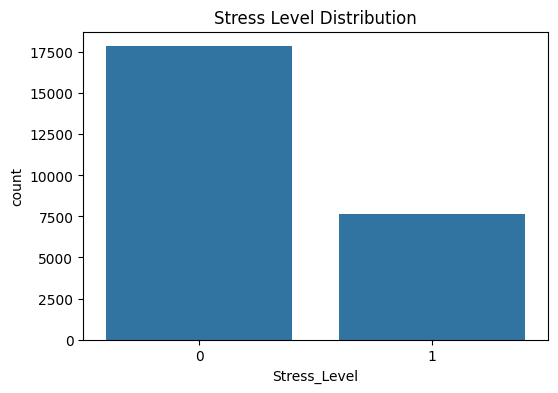

In [325]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Stress_Level")

plt.title("Stress Level Distribution")
plt.show()

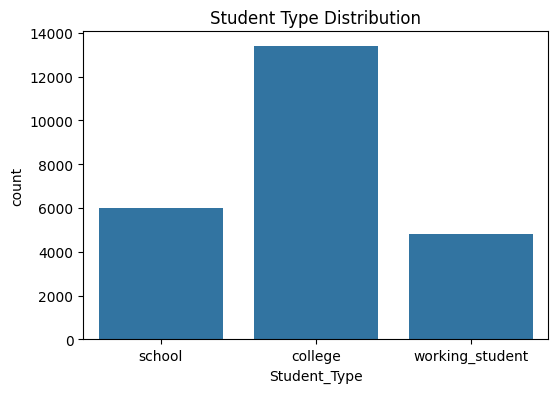

In [326]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Student_Type")

plt.title("Student Type Distribution")
plt.show()

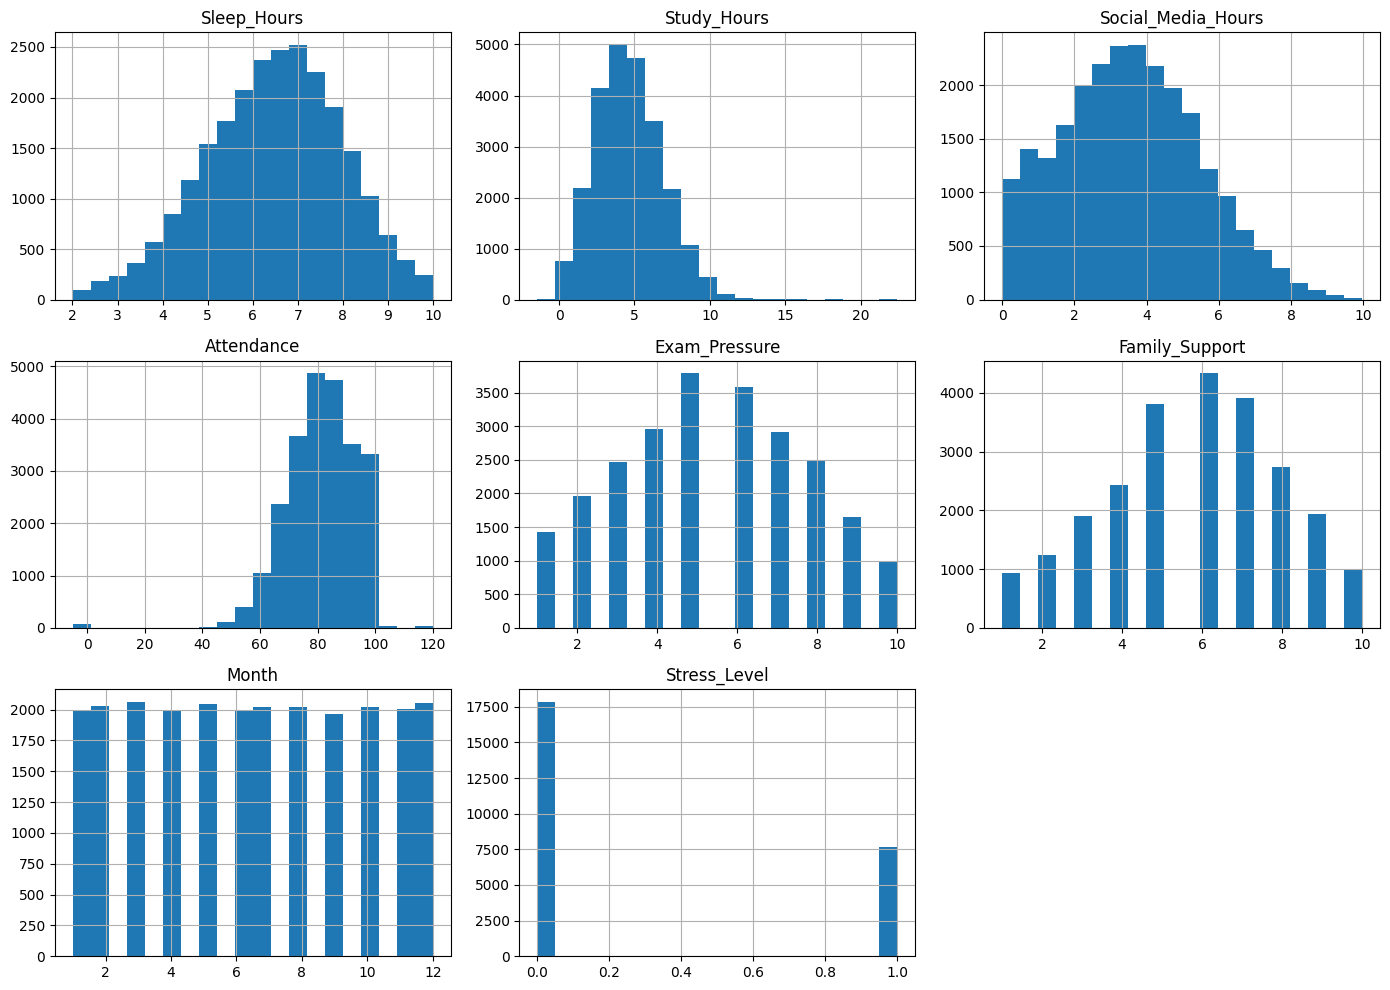

In [327]:
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

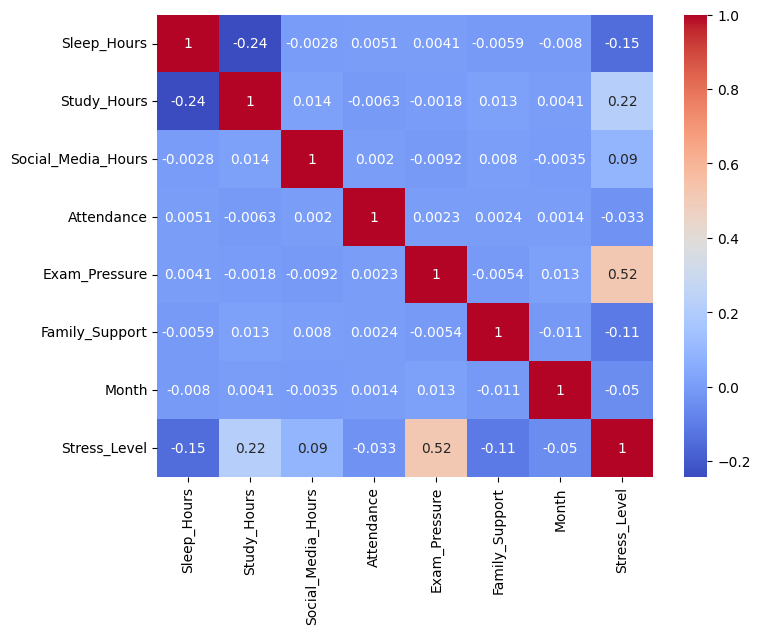

In [328]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

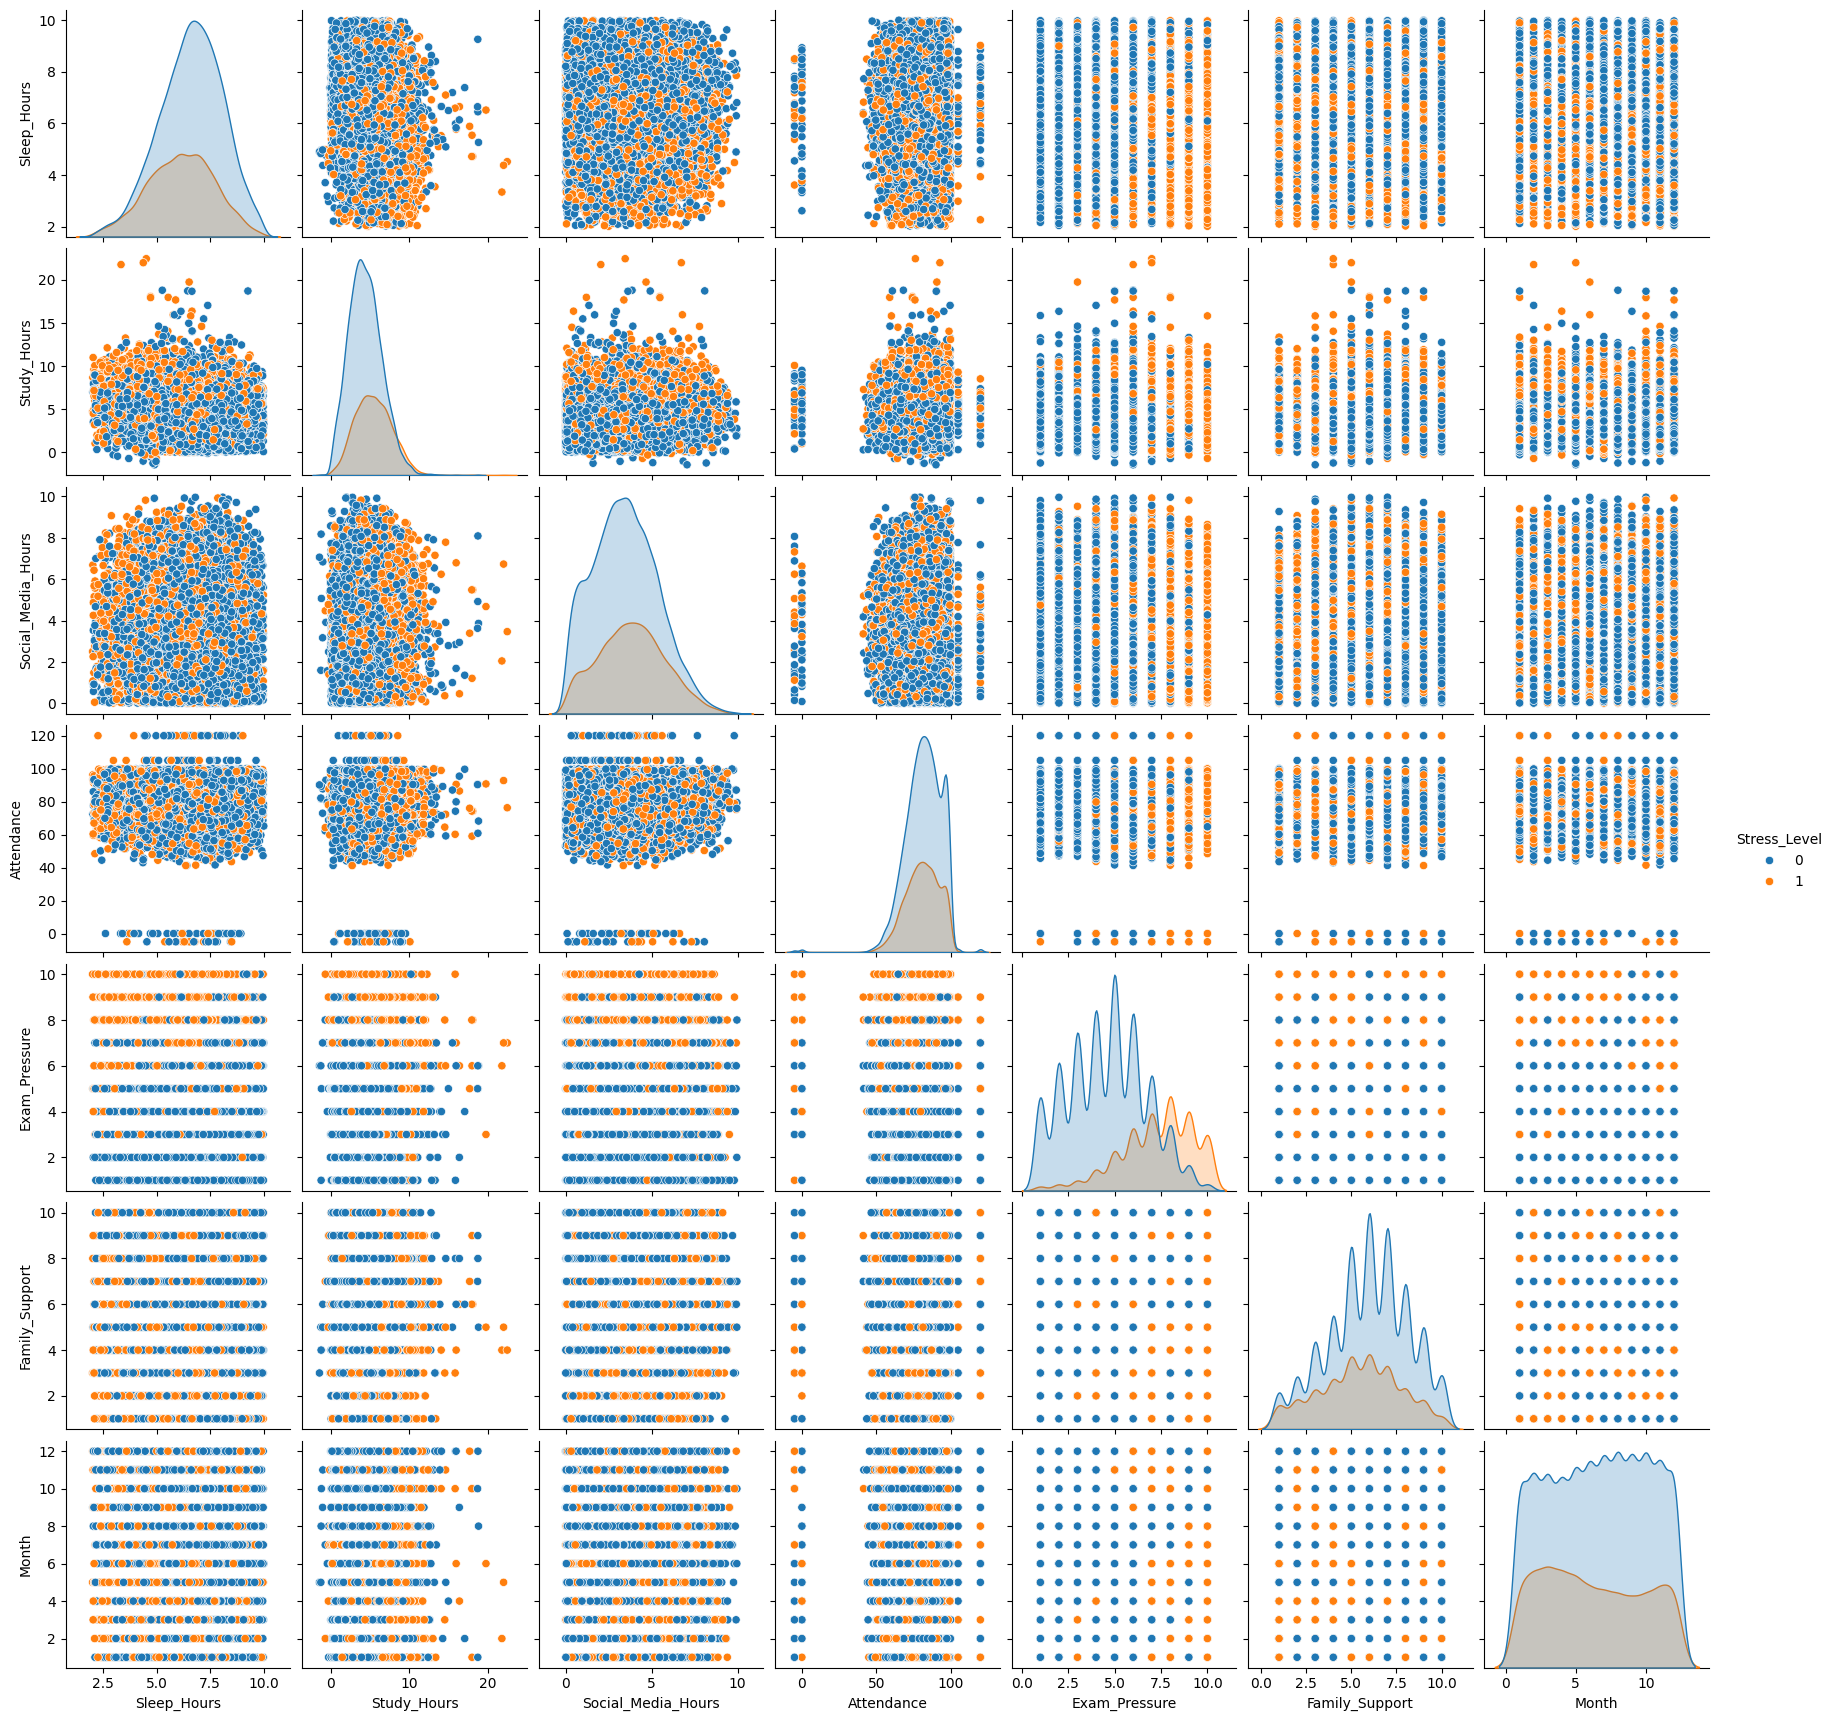

In [329]:
sns.pairplot(df, hue="Stress_Level")

plt.show()

In [330]:
df_clean = df.copy()

In [331]:
df_clean.isnull().sum()

,0
Student_Type,1252
Sleep_Hours,1333
Study_Hours,1277
Social_Media_Hours,1312
Attendance,1305
Exam_Pressure,1270
Family_Support,1291
Month,1314
Stress_Level,0


In [332]:
(df_clean.isnull().mean() * 100).sort_values(ascending=False)

,0
Sleep_Hours,5.227451
Month,5.152941
Social_Media_Hours,5.145098
Attendance,5.117647
Family_Support,5.062745
Study_Hours,5.007843
Exam_Pressure,4.980392
Student_Type,4.909804
Stress_Level,0.000000


In [333]:
df_clean.drop_duplicates(inplace=True)

In [334]:
df_clean.duplicated().sum()

np.int64(0)

In [335]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

In [336]:
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

In [337]:
categorical_cols = df_clean.select_dtypes(include="object").columns

In [338]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [339]:
df_clean.isnull().sum()

,0
Student_Type,0
Sleep_Hours,0
Study_Hours,0
Social_Media_Hours,0
Attendance,0
Exam_Pressure,0
Family_Support,0
Month,0
Stress_Level,0


In [340]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25476 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        25476 non-null  object 
 1   Sleep_Hours         25476 non-null  float64
 2   Study_Hours         25476 non-null  float64
 3   Social_Media_Hours  25476 non-null  float64
 4   Attendance          25476 non-null  float64
 5   Exam_Pressure       25476 non-null  float64
 6   Family_Support      25476 non-null  float64
 7   Month               25476 non-null  float64
 8   Stress_Level        25476 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.9+ MB


In [341]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,25476.0,6.463091,1.464487,2.008586,5.510233,6.542207,7.473658,9.997527
Study_Hours,25476.0,4.688690,2.184630,-1.433434,3.157381,4.538138,6.035742,22.444460
Social_Media_Hours,25476.0,3.552719,1.852293,0.000040,2.234549,3.501057,4.774688,9.962134
Attendance,25476.0,81.302928,11.740114,-5.000000,74.280603,81.941554,89.580536,120.000000
Exam_Pressure,25476.0,5.351311,2.334919,1.000000,4.000000,5.000000,7.000000,10.000000
Family_Support,25476.0,5.807976,2.175324,1.000000,4.000000,6.000000,7.000000,10.000000
Month,25476.0,6.475389,3.366705,1.000000,4.000000,6.000000,9.000000,12.000000
Stress_Level,25476.0,0.299851,0.458201,0.000000,0.000000,0.000000,1.000000,1.000000


In [342]:
df_clean[df_clean["Sleep_Hours"] > 24]

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level


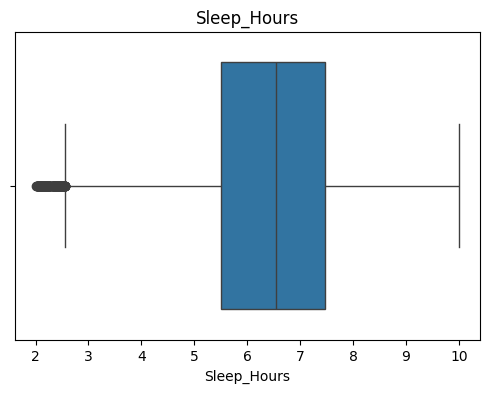

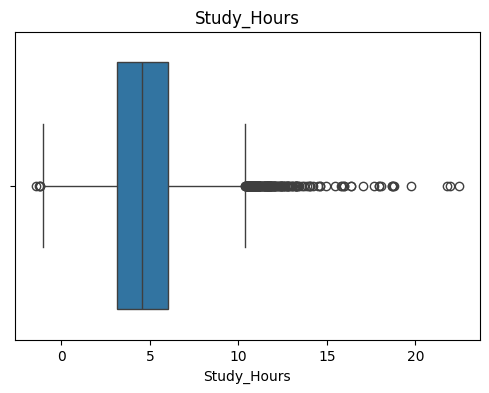

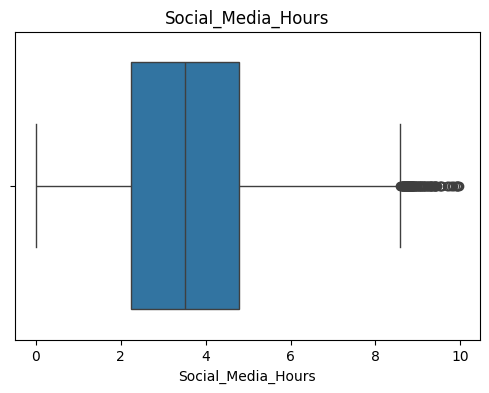

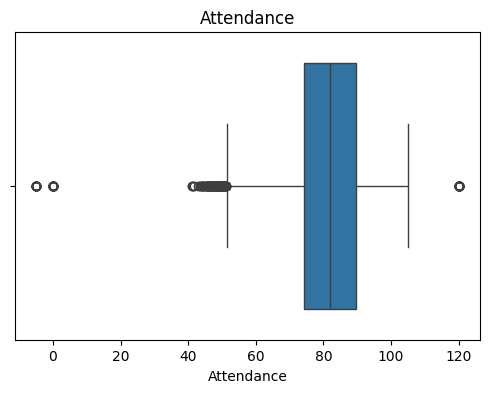

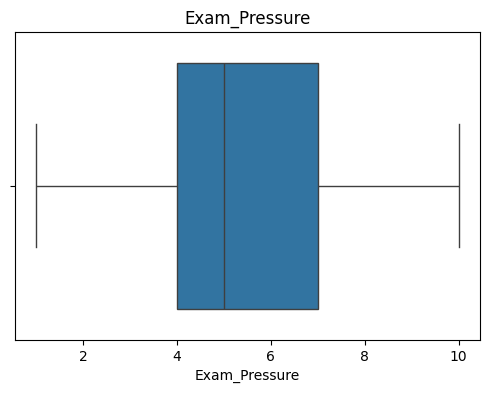

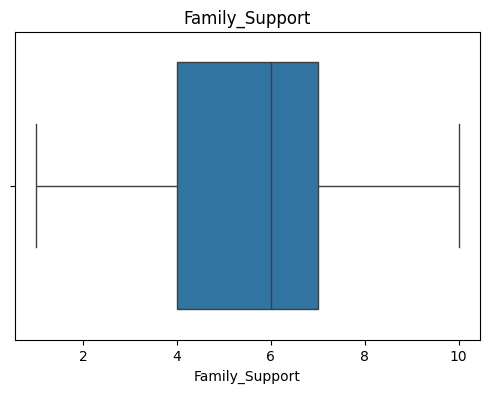

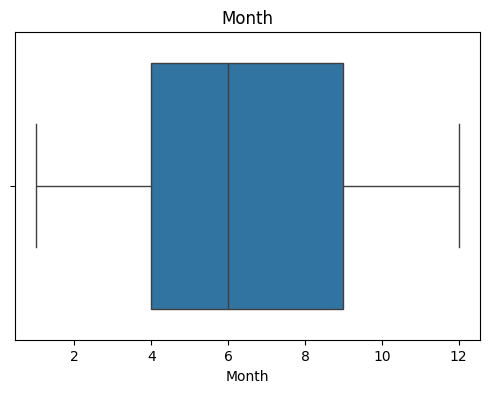

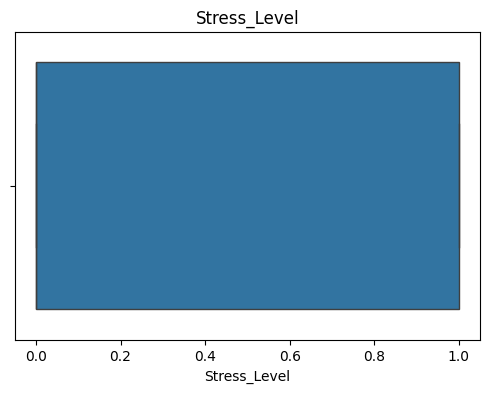

In [343]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

In [344]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.drop("Stress_Level")

In [345]:
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

In [346]:
print("Shape after removing outliers:", df_clean.shape)

Shape after removing outliers: (24733, 9)


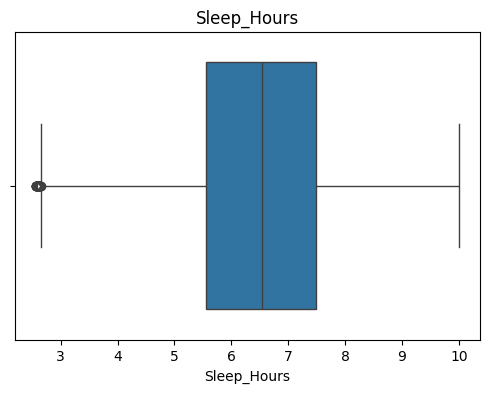

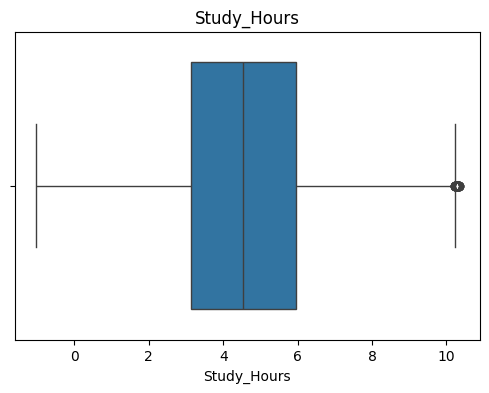

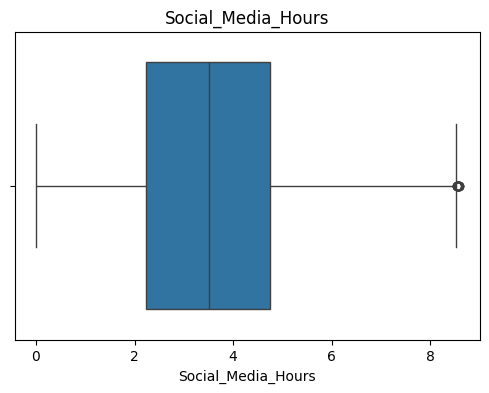

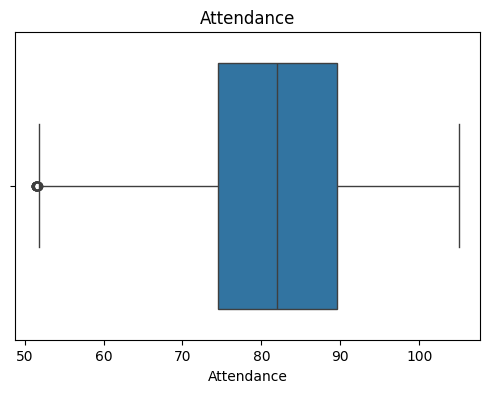

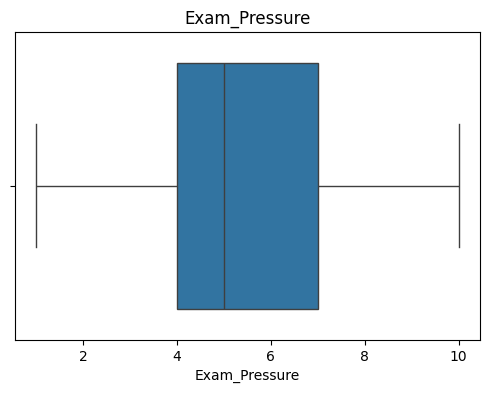

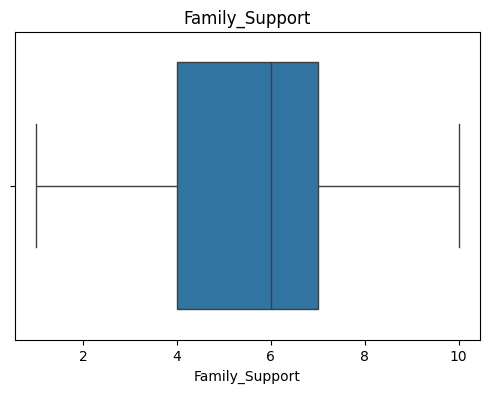

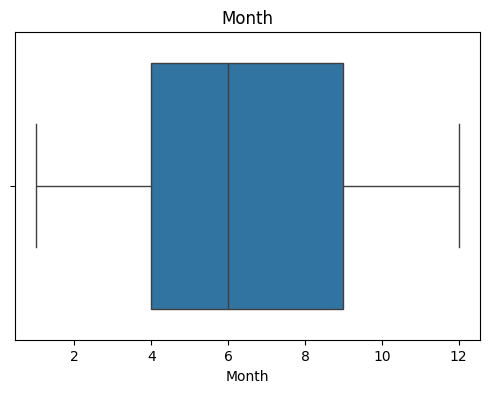

In [347]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

In [348]:
X = df_clean.drop("Stress_Level", axis=1)
y = df_clean["Stress_Level"]

In [349]:
le = LabelEncoder()

In [350]:
df_clean["Student_Type"] = le.fit_transform(df_clean["Student_Type"])

In [351]:
df_clean.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,1,6.868702,1.711722,3.176942,81.941554,8.0,7.0,2.0,1
1,1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,0,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,1,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,0,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [352]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'college': np.int64(0), 'school': np.int64(1), 'working_student': np.int64(2)}


In [353]:
X = df_clean.drop("Stress_Level", axis=1)
y = df_clean["Stress_Level"]

In [354]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (24733, 8)
y Shape: (24733,)


In [355]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [356]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (19786, 8)
X_test : (4947, 8)
y_train: (19786,)
y_test : (4947,)


In [357]:
scaler = StandardScaler()

In [358]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [359]:
lr = LogisticRegression(random_state=42)

In [360]:
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [361]:
y_pred = lr.predict(X_test_scaled)

In [362]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [363]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [364]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8219122700626642


In [365]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.7359413202933985


In [366]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6184931506849315


In [367]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.6721250465202828


In [368]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3487
           1       0.74      0.62      0.67      1460

    accuracy                           0.82      4947
   macro avg       0.79      0.76      0.77      4947
weighted avg       0.82      0.82      0.82      4947



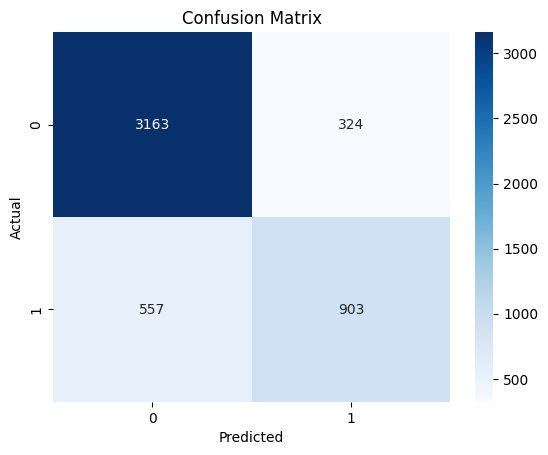

In [369]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [370]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8746653912182627


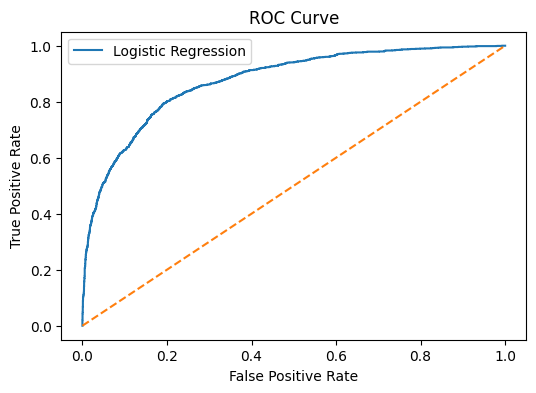

In [371]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [372]:
from xgboost import XGBRFClassifier

In [373]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=XGBRFClassifier(n_estimators=800,
                      max_depth=8,
                      learning_rate=1,
                      eval_metric=('logloss'),
                       subsample=0.6,
                      colsample_bytree=0.8,
                      random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
print("XGBoost accuracy", accuracy_score(y_test,pred))

XGBoost accuracy 0.8085708510208207


In [375]:
print("Precision:", precision_score(y_test,pred))

Precision: 0.7602283539486203


In [376]:
print("Recall :", recall_score(y_test,pred))

Recall : 0.534805890227577


In [377]:
print("F1 Score :", f1_score(y_test,pred))

F1 Score : 0.6278978388998036


In [378]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      3453
           1       0.76      0.53      0.63      1494

    accuracy                           0.81      4947
   macro avg       0.79      0.73      0.75      4947
weighted avg       0.80      0.81      0.80      4947



In [379]:
y_predct= model.predict(X_test)

In [380]:
y_prob = model.predict_proba(X_test)[:,1]

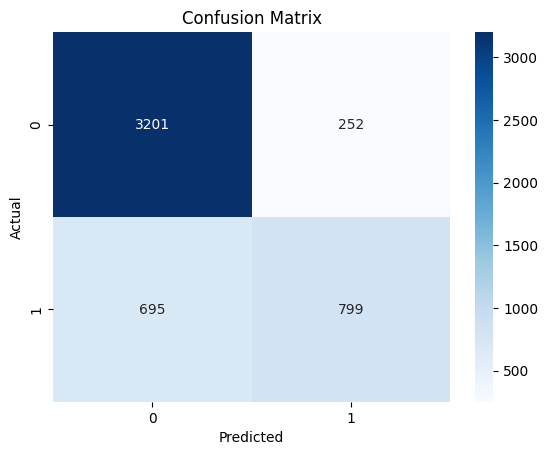

In [381]:
cm = confusion_matrix(y_test, y_predct)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [382]:
print("ROC-AUC:", roc_auc_score(y_test,y_prob))

ROC-AUC: 0.8601105842425596


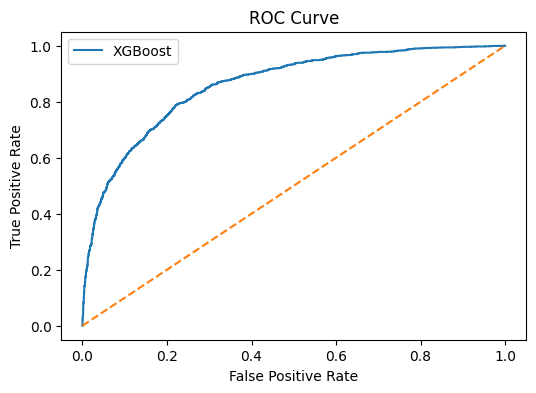

In [383]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()